This notebook reproduces Figure 3 in "Humidity’s role in population heat-health risk" by Kong et al.

In [1]:
"""
import python packages
please install required packages before running this notebook
"""
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# Nature Communications artwork requirements: sans-serif font, preferably Helvetica/Arial
# (Liberation Sans is metrically identical to Arial); text 5-7 pt at final print size;
# vector PDF with true (editable) embedded fonts, not the Type 3 fonts matplotlib embeds
# by default
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Liberation Sans', 'Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Liberation Sans'
plt.rcParams['mathtext.it'] = 'Liberation Sans:italic'
plt.rcParams['mathtext.bf'] = 'Liberation Sans:bold'


In [2]:
# read in Japan prefecture-level effective beta of existing heat stress indices
HSI_beta=xr.open_dataset('../data/Prefecture_level_HSI_effective_beta.nc').beta

# read in mean absolute prediction error of GHSI
mae=xr.open_dataset('../data/GHSI_MAE.nc').MAE
# calculate optimal beta with lowest MAE for outdoor GHSI
optimal_beta=mae.sel(exposure='outdoor').idxmin(dim='beta')

findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.


findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


Figure size (mm): [ 88.011 198.628]


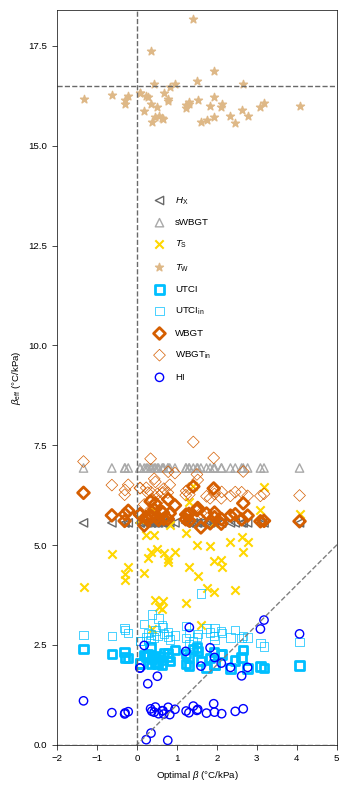

In [3]:
fig = plt.figure(figsize=(3.465, 7.820))  # width fixed at NC 1-column (88 mm); height
                                          # follows from equal-aspect axes filling that
                                          # width, given the x/y data ranges (7 vs 18.4)
fig.subplots_adjust(left=0.1591, right=0.9659, bottom=0.0453, top=0.9849)
ax = fig.add_subplot(111)
x=optimal_beta # x variable as calibrated optimal beta for each prefecture

ax.scatter(x, HSI_beta.sel(var='Hx'), marker='<',facecolors='none', edgecolors='dimgray',label=r'$H_{\mathrm{X}}$') # Humidex
ax.scatter(x, HSI_beta.sel(var='sWBGT'), marker='^',facecolors='none', edgecolors='darkgray',label='sWBGT') # simplified WBGT
ax.scatter(x, HSI_beta.sel(var='Ts'), marker='x',c='gold',label=r'$T_{\mathrm{S}}$') # lethal temperature
ax.scatter(x, HSI_beta.sel(var='Tw'), marker='*',c='burlywood',label=r'$T_{\mathrm{W}}$') # wet-bulb temperature
ax.scatter(x, HSI_beta.sel(var='UTCI'), marker='s', facecolors='none', edgecolors='deepskyblue', linewidths=2,label='UTCI') # outdoor UTCI
ax.scatter(x, HSI_beta.sel(var='UTCIin'), marker='s', facecolors='none', edgecolors='deepskyblue', linewidths=0.5,label=r'$\mathrm{UTCI}_{\mathrm{in}}$') # indoor UTCI
ax.scatter(x, HSI_beta.sel(var='WBGT'), marker='D', facecolors='none', edgecolors='#D55E00', linewidths=2,label='WBGT') # outdoor WBGT
ax.scatter(x, HSI_beta.sel(var='WBGTin'), marker='D', facecolors='none', edgecolors='#D55E00', linewidths=0.5,label=r'$\mathrm{WBGT}_{\mathrm{in}}$') # indoor WBGT
ax.scatter(x, HSI_beta.sel(var='HI'),marker='o',facecolors='none', edgecolors='blue',label='HI') # Heat Index

ax.set_xlabel(r'Optimal $\beta$ (°C/kPa)', fontsize=7)
ax.set_ylabel(r'$\beta_{\mathrm{eff}}$ (°C/kPa)', fontsize=7)
ax.set_xlim(-2,5)
ax.set_ylim(0,18.4)
ax.plot([-2, 18.2], [-2, 18.2], color='gray', linestyle='--', linewidth=1)

ax.set_aspect('equal', adjustable='box') # set square aspect ratio
ax.axhline(y=16.5, color='dimgrey', linestyle='--', linewidth=1)
ax.axhline(y=0, color='dimgrey', linestyle='--', linewidth=1)
ax.axvline(x=0, color='dimgrey', linestyle='--', linewidth=1)

ax.legend(loc='upper left', bbox_to_anchor=(0.3, 0.76),frameon=False,fontsize=7,
          labelspacing=1.2, handletextpad=0.6)
ax.tick_params(axis='both', labelsize=7, width=0.5)
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

out_dir = '/home/kong97/coding/optimal_metric/Japan/revision/plot/publication_data_share'
fig.savefig(f'{out_dir}/Figure3_v2.pdf', bbox_inches=None)
print('Figure size (mm):', fig.get_size_inches()*25.4)


**Figure 3**. Optimal $\beta$ calibrated for the outdoor formulation of General Heat Stress Index (GHSI, x-axis) versus $\beta_{eff}$ of existing heat stress indices (y-axis), with each point representing one prefecture. The diagonal 1:1 line indicates agreement between the two types of $\beta$ values, and the horizontal dashed line marks the theoretical upper bound of 16.5 $^\circ$C/kPa.